# Gaussian Drift OPT Debug

Minimal notebook for testing only the homogeneous Gaussian initial-condition drift. FD is the control; OPT is the object under test. Shared helpers live in `temporaryHelpers.jl`.

## 1. Setup

In [1]:
using Pkg
cd(@__DIR__)
Pkg.activate("../")

try
    using Metal
catch err
    @warn "Metal not loaded; continuing on CPU" err
end
ParamFile = "../config/testparam.csv"

include("../src/batchFiles/batchGPU.jl")
include("../src/commonBatchs.jl")
include("../src/planet1D.jl")
include("../src/GeoPoints.jl")
using .commonBatchs, .planet1D, .GeoPoints

include("../src/flexOPT.jl")
using .flexOPT

include("temporaryHelpers.jl")


  Activating 

devs = Metal.devices() = Metal.MTL.MTLDeviceInstance[Metal.MTL.MTLDeviceInstance (object of type AGXG13XDevice)]

project at `~/Documents/Github/flexOPT`



→ Using Metal backend (1 device(s))
Selected backend type: MetalBackend


stencil_time_summary (generic function with 1 method)

## 2. Controls And Initial Gaussian

In [2]:
# Homogeneous toy controls
shape = (201, 201)
velocity_value = 2600.0
dx = 100.0
cfl = 0.45
Nt = 180
store_every = 3
sigma = 10.0
amplitude = 1.0

# OPT controls
pointsInSpace = 3
pointsInTime = 3
supplementaryOrder = 2
orderBspace = 1
orderBtime = 1

center = CartesianIndex(cld(shape[1], 2), cld(shape[2], 2))
dt = cfl * dx / velocity_value
delta = (dx, dx, dt)
velocity = fill(velocity_value, shape)
init_gaussian = gaussian_field(shape, center; sigma=sigma, amplitude=amplitude)

@show shape center velocity_value delta sigma Nt store_every


shape = (201, 201)
center = CartesianIndex(101, 101)
velocity_value = 2600.0
delta = (100.0, 100.0, 0.01730769230769231)
sigma = 10.0
Nt = 180
store_every = 3


3

## 3. FD Baseline

In [3]:
preparedFD = prepare_fd2d_acoustic_baseline(velocity, delta)
frames_fd = propagate_linear_frames_from_initial(
    preparedFD,
    init_gaussian,
    init_gaussian,
    Nt;
    store_every=store_every,
    blowup_limit=1e12,
)

fd_report = wavefield_snapshot_report(frames_fd)
fd_drift = drift_report(frames_fd, center)
fd_argmax = argmax_report(frames_fd, center)
fd_symmetry = symmetry_report(frames_fd, center)

@show length(frames_fd) fd_report[1] fd_report[end]
@show fd_drift[1] fd_drift[end]
@show fd_argmax[1] fd_argmax[end]
@show fd_symmetry[1] fd_symmetry[end]


length(frames_fd) = 61
fd_report[1] = (frame = 1, nbad = 0, finite_max = 1.0, minimum = 3.720075976020836e-44, maximum = 1.0)
fd_report[end] = (frame = 61, nbad = 0, finite_max = 0.12650212646124115, minimum = -0.07299382461789063, maximum = 0.12650212646124115)
fd_drift[1] = (frame = 1, cm_x = 100.99999999999979, cm_z = 101.00000000000017, drift_x = -2.1316282072803006e-13, drift_z = 1.7053025658242404e-13, maxabs = 1.0)
fd_drift[end] = (frame = 61, cm_x = 101.00000000000011, cm_z = 100.99999999999959, drift_x = 1.1368683772161603e-13, drift_z = -4.121147867408581e-13, maxabs = 0.12650212646124115)
fd_argmax[1] = (frame = 1, maxpoint = CartesianIndex(101, 101), dx = 0, dz = 0, value = 1.0, maxabs = 1.0)
fd_argmax[end] = (frame = 61, maxpoint = CartesianIndex(43, 165), dx = -58, dz = 64, value = 0.12650212646124115, maxabs = 0.12650212646124115)
fd_symmetry[1] = (frame = 1, lr = 0.0, ud = 0.0, diag = 0.0)
fd_symmetry[end] = (frame = 61, lr = 1.1842581322338107e-15, ud = 1.3256361873321

(frame = 61, lr = 1.1842581322338107e-15, ud = 1.325636187332138e-15, diag = 1.412088476802089e-15)

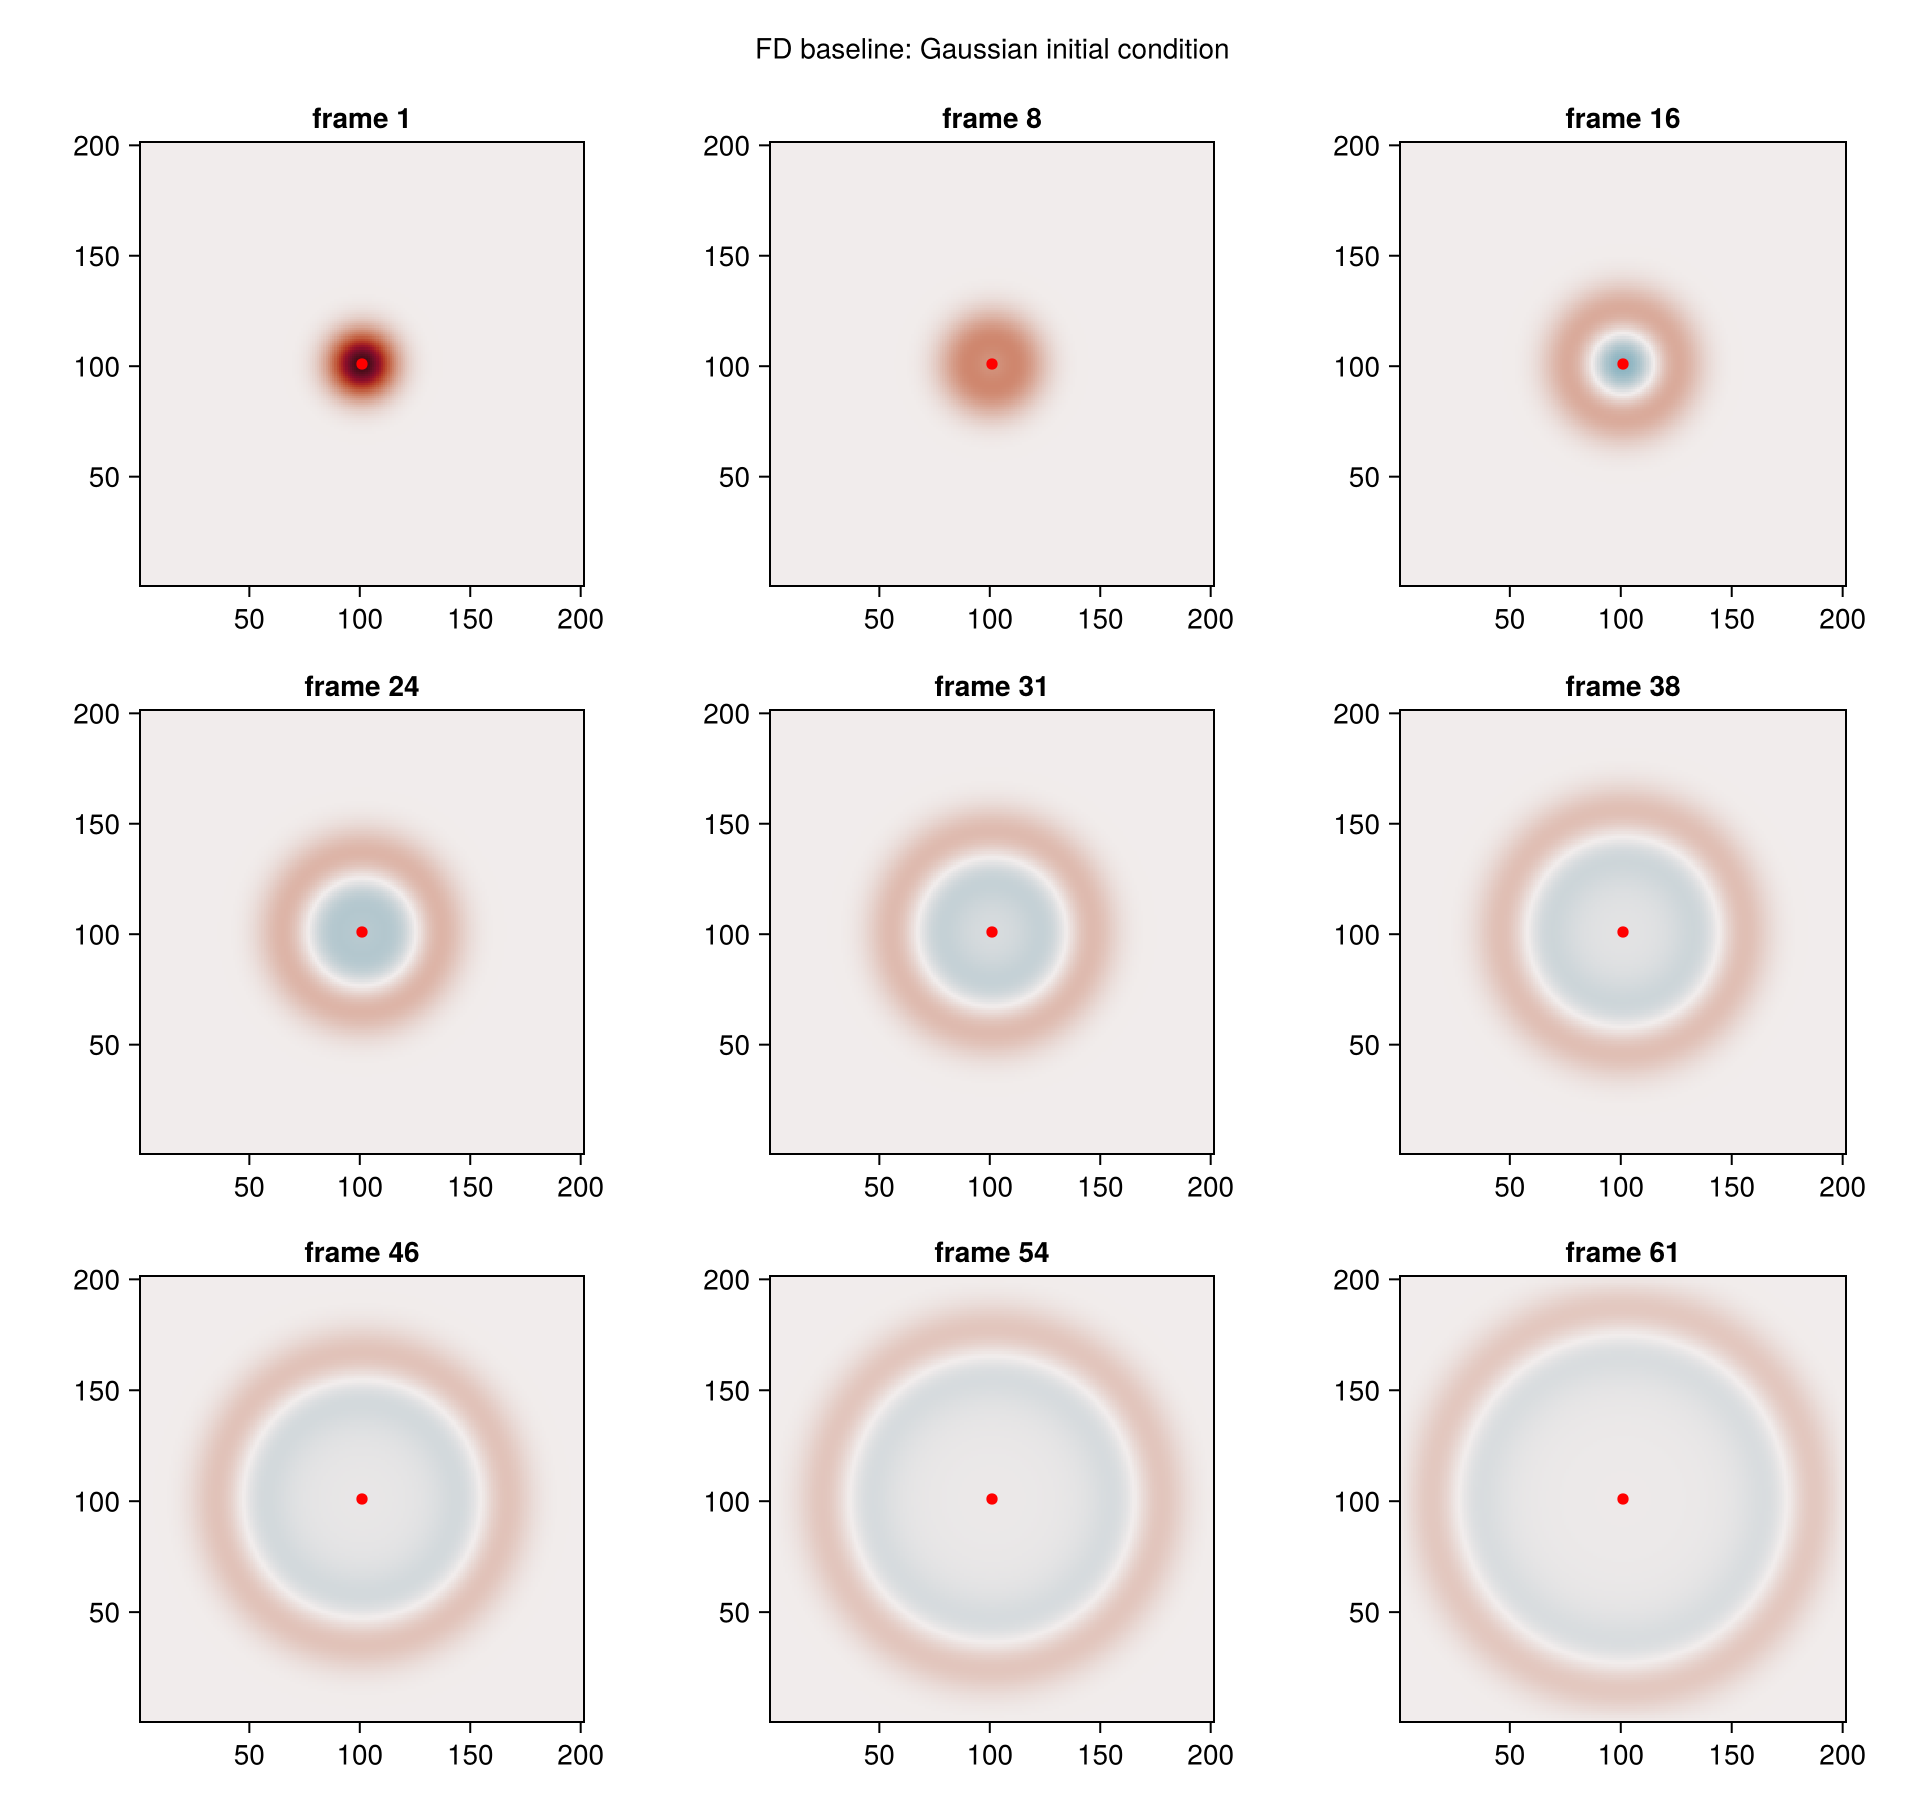

In [4]:
fig_fd = plot_wave_snapshots(
    frames_fd;
    sourcePoint=center,
    title="FD baseline: Gaussian initial condition",
)
fig_fd


## 4. OPT Build

In [5]:
toyOPT = build_toy_opt_prepared(
    velocity_value=velocity_value,
    shape=shape,
    dx=dx,
    cfl=cfl,
    pointsInSpace=pointsInSpace,
    pointsInTime=pointsInTime,
    supplementaryOrder=supplementaryOrder,
    orderBspace=orderBspace,
    orderBtime=orderBtime,
)
preparedOPT = toyOPT.prepared

@show preparedOPT.spaceShape preparedOPT.NpointsSpace preparedOPT.NField preparedOPT.NForceField preparedOPT.timePointsUsedForOneStep
@show size(preparedOPT.A_unknown) nnz(preparedOPT.A_unknown) nnz(preparedOPT.L_known)

opt_A_report = implicit_matrix_report(preparedOPT)
@show opt_A_report


(vars, iVars) = (v(x, y), 1)
(vars, iVars) = (v(x, y), 1)
pointsIndices = availablePointsConfigurations[iConfigGeometry] = SVector{3, Int64}[[1, 1, 1] [1, 2, 1] [1, 3, 1]; [2, 1, 1] [2, 2, 1] [2, 3, 1]; [3, 1, 1] [3, 2, 1] [3, 3, 1];;; [1, 1, 2] [1, 2, 2] [1, 3, 2]; [2, 1, 2] [2, 2, 2] [2, 3, 2]; [3, 1, 2] [3, 2, 2] [3, 3, 2];;; [1, 1, 3] [1, 2, 3] [1, 3, 3]; [2, 1, 3] [2, 2, 3] [2, 3, 3]; [3, 1, 3] [3, 2, 3] [3, 3, 3]]
middleLinearν = centrePointConfigurations[iConfigGeometry] = 14
μPoints = availableμPoints[iConfigGeometry] = SVector{3, Float64}[[2.0, 2.0, 2.0];;;]
μᶜPoints = availableμᶜPoints[iConfigGeometry] = SVector{3, Float64}[[2.0, 2.0, 2.0];;;]
μaxes = availableμaxes[iConfigGeometry] = ([2.0], [2.0], [2.0])
μᶜaxes = availableμᶜaxes[iConfigGeometry] = ([2.0], [2.0], [2.0])
size(μPoints) = (1, 1, 1)
pointν = pointsIndices[middleLinearν] = [2, 2, 2]
(typeof(μPoints), μPoints[1], typeof(pointsIndices)) = (Array{SVector{3, Float64}, 3}, [2.0, 2.0, 2.0], Array{SVector{3, Int64}, 3})

(size = (40401, 40401), nnz = 361201, stored_finite = 361201, stored_nonfinite = 0, stored_nan = 0, stored_inf = 0, zero_rows_finite = 0, rows_with_nonfinite = 0, finite_abs_min = 1.1571303488240596e-22, finite_abs_median = 2.90794940549532e-9, finite_abs_max = 5.079253057108472e-8, diag_finite_count = 40401, diag_nonfinite_count = 0, diag_abs_min = 5.079253057108472e-8, diag_abs_median = 5.079253057108472e-8, diag_abs_max = 5.079253057108472e-8, finite_row_abs_min = 5.989989070779101e-8, finite_row_abs_max = 1.1178250227642247e-7)

In [6]:
toyOPT.optRec["recette"].lhs.Ajiννᶜ

27×1×1×1 Array{Symbolics.Num, 4}:
[:, :, 1, 1] =
     5.215803943715839e-23 - 3.71709888639398e-32(v₁^2) - 3.2266483381243443e-19(v₂^2) - 7.818262883769384e-32(v₃^2) - 3.2266483356882023e-19(v₄^2) + 2.714835152267093e-18(v₅^2) - 1.0347527424367115e-18(v₆^2) - 7.818725239523447e-32(v₇^2) - 1.0347527424809049e-18(v₈^2) - 1.1920351589894512e-31(v₉^2)
         7.890209852882007e-10 - 3.2266483533015114e-19(v₁^2) - 2.8974931314506753e-6(v₂^2) - 6.341635527192951e-19(v₃^2) - 2.7043269226187344e-6(v₄^2) + 2.3566277468392972e-5(v₅^2) - 8.112980767808582e-6(v₆^2) - 7.232142858215485e-19(v₇^2) - 9.851476646788371e-6(v₈^2) - 1.0347527468242072e-18(v₉^2)
     1.7466931162715983e-22 + 5.714280543360853e-32(v₁^2) + 3.514013093650331e-19(v₂^2) + 1.4160589936341662e-31(v₃^2) + 6.406612847137714e-19(v₄^2) - 4.086542026248788e-18(v₅^2) + 2.1071690973280638e-18(v₆^2) + 9.377116524686849e-32(v₇^2) + 9.873103349071707e-19(v₈^2) + 1.7824201523203797e-31(v₉^2)
            1.1166770071634295e-10 - 3.226648353

In [7]:
audit = recipe_local_index_audit(toyOPT.optRec)
audit

27-element Vector{NamedTuple}:
 (linear = 1, cartesian_index = (1, 1, 1), local_point = (1, 1, 1), offset = (-1, -1, -1), spatial_offset = (-1, -1), time_slot = 1, time_role = :past_2)
 (linear = 2, cartesian_index = (2, 1, 1), local_point = (2, 1, 1), offset = (0, -1, -1), spatial_offset = (0, -1), time_slot = 1, time_role = :past_2)
 (linear = 3, cartesian_index = (3, 1, 1), local_point = (3, 1, 1), offset = (1, -1, -1), spatial_offset = (1, -1), time_slot = 1, time_role = :past_2)
 (linear = 4, cartesian_index = (1, 2, 1), local_point = (1, 2, 1), offset = (-1, 0, -1), spatial_offset = (-1, 0), time_slot = 1, time_role = :past_2)
 (linear = 5, cartesian_index = (2, 2, 1), local_point = (2, 2, 1), offset = (0, 0, -1), spatial_offset = (0, 0), time_slot = 1, time_role = :past_2)
 (linear = 6, cartesian_index = (3, 2, 1), local_point = (3, 2, 1), offset = (1, 0, -1), spatial_offset = (1, 0), time_slot = 1, time_role = :past_2)
 (linear = 7, cartesian_index = (1, 3, 1), local_point = (1

In [8]:
center = CartesianIndex(cld(size(toyOPT.velocity,1),2), cld(size(toyOPT.velocity,2),2))

st = operator_stencil_at_point(toyOPT.numOps, center; which=:left, iExpr=1, iField=1)
stencil_time_summary(st)
st

27-element Vector{NamedTuple}:
 (time_slot = 1, time_role = :past_2, offset = (-1, -1), coef = -1.6477417736694094e-22, abscoef = 1.6477417736694094e-22, col = 59995)
 (time_slot = 1, time_role = :past_2, offset = (-1, 0), coef = -1.7898248122921792e-9, abscoef = 1.7898248122921792e-9, col = 60598)
 (time_slot = 1, time_role = :past_2, offset = (-1, 1), coef = 6.17530229256566e-23, abscoef = 6.17530229256566e-23, col = 61201)
 (time_slot = 1, time_role = :past_2, offset = (0, -1), coef = -1.077455981700553e-9, abscoef = 1.077455981700553e-9, col = 59998)
 (time_slot = 1, time_role = :past_2, offset = (0, 0), coef = 1.7153950821117613e-8, abscoef = 1.7153950821117613e-8, col = 60601)
 (time_slot = 1, time_role = :past_2, offset = (0, 1), coef = 2.863133845371789e-9, abscoef = 2.863133845371789e-9, col = 61204)
 (time_slot = 1, time_role = :past_2, offset = (1, -1), coef = 6.18947274886691e-22, abscoef = 6.18947274886691e-22, col = 60001)
 (time_slot = 1, time_role = :past_2, offset = (1

## 5. OPT Propagation

In [9]:
frames_opt = propagate_linear_frames_from_initial(
    preparedOPT,
    init_gaussian,
    init_gaussian,
    Nt;
    store_every=store_every,
    blowup_limit=1e12,
)

opt_report = wavefield_snapshot_report(frames_opt)
opt_drift = drift_report(frames_opt, center)
opt_argmax = argmax_report(frames_opt, center)
opt_symmetry = symmetry_report(frames_opt, center)

@show length(frames_opt) opt_report[1] opt_report[end]
@show opt_drift[1] opt_drift[end]
@show opt_argmax[1] opt_argmax[end]
@show opt_symmetry[1] opt_symmetry[end]


┌ Warning: Stopping because wavefield blew up
│   it = 25
│   umax = 2.5823860093739683e12
│   blowup_limit = 1.0e12
└ @ Main /Users/nobuaki/Documents/Github/flexOPT/notebooks/temporaryHelpers.jl:156


length(frames_opt) = 10
opt_report[1] = (frame = 1, nbad = 0, finite_max = 1.0, minimum = 3.720075976020836e-44, maximum = 1.0)
opt_report[end] = (frame = 10, nbad = 0, finite_max = 2.5823860093739683e12, minimum = -2.5823860093739683e12, maximum = 0.0065949441500145695)
opt_drift[1] = (frame = 1, cm_x = 100.99999999999979, cm_z = 101.00000000000017, drift_x = -2.1316282072803006e-13, drift_z = 1.7053025658242404e-13, maxabs = 1.0)
opt_drift[end] = (frame = 10, cm_x = 99.22004372893048, cm_z = 102.95117398177938, drift_x = -1.7799562710695227, drift_z = 1.9511739817793767, maxabs = 2.5823860093739683e12)
opt_argmax[1] = (frame = 1, maxpoint = CartesianIndex(101, 101), dx = 0, dz = 0, value = 1.0, maxabs = 1.0)
opt_argmax[end] = (frame = 10, maxpoint = CartesianIndex(99, 103), dx = -2, dz = 2, value = -2.5823860093739683e12, maxabs = 2.5823860093739683e12)
opt_symmetry[1] = (frame = 1, lr = 0.0, ud = 0.0, diag = 0.0)
opt_symmetry[end] = (frame = 10, lr = 0.1414206762996639, ud = 0.15579

(frame = 10, lr = 0.1414206762996639, ud = 0.15579776570420556, diag = 0.21031061388828773)

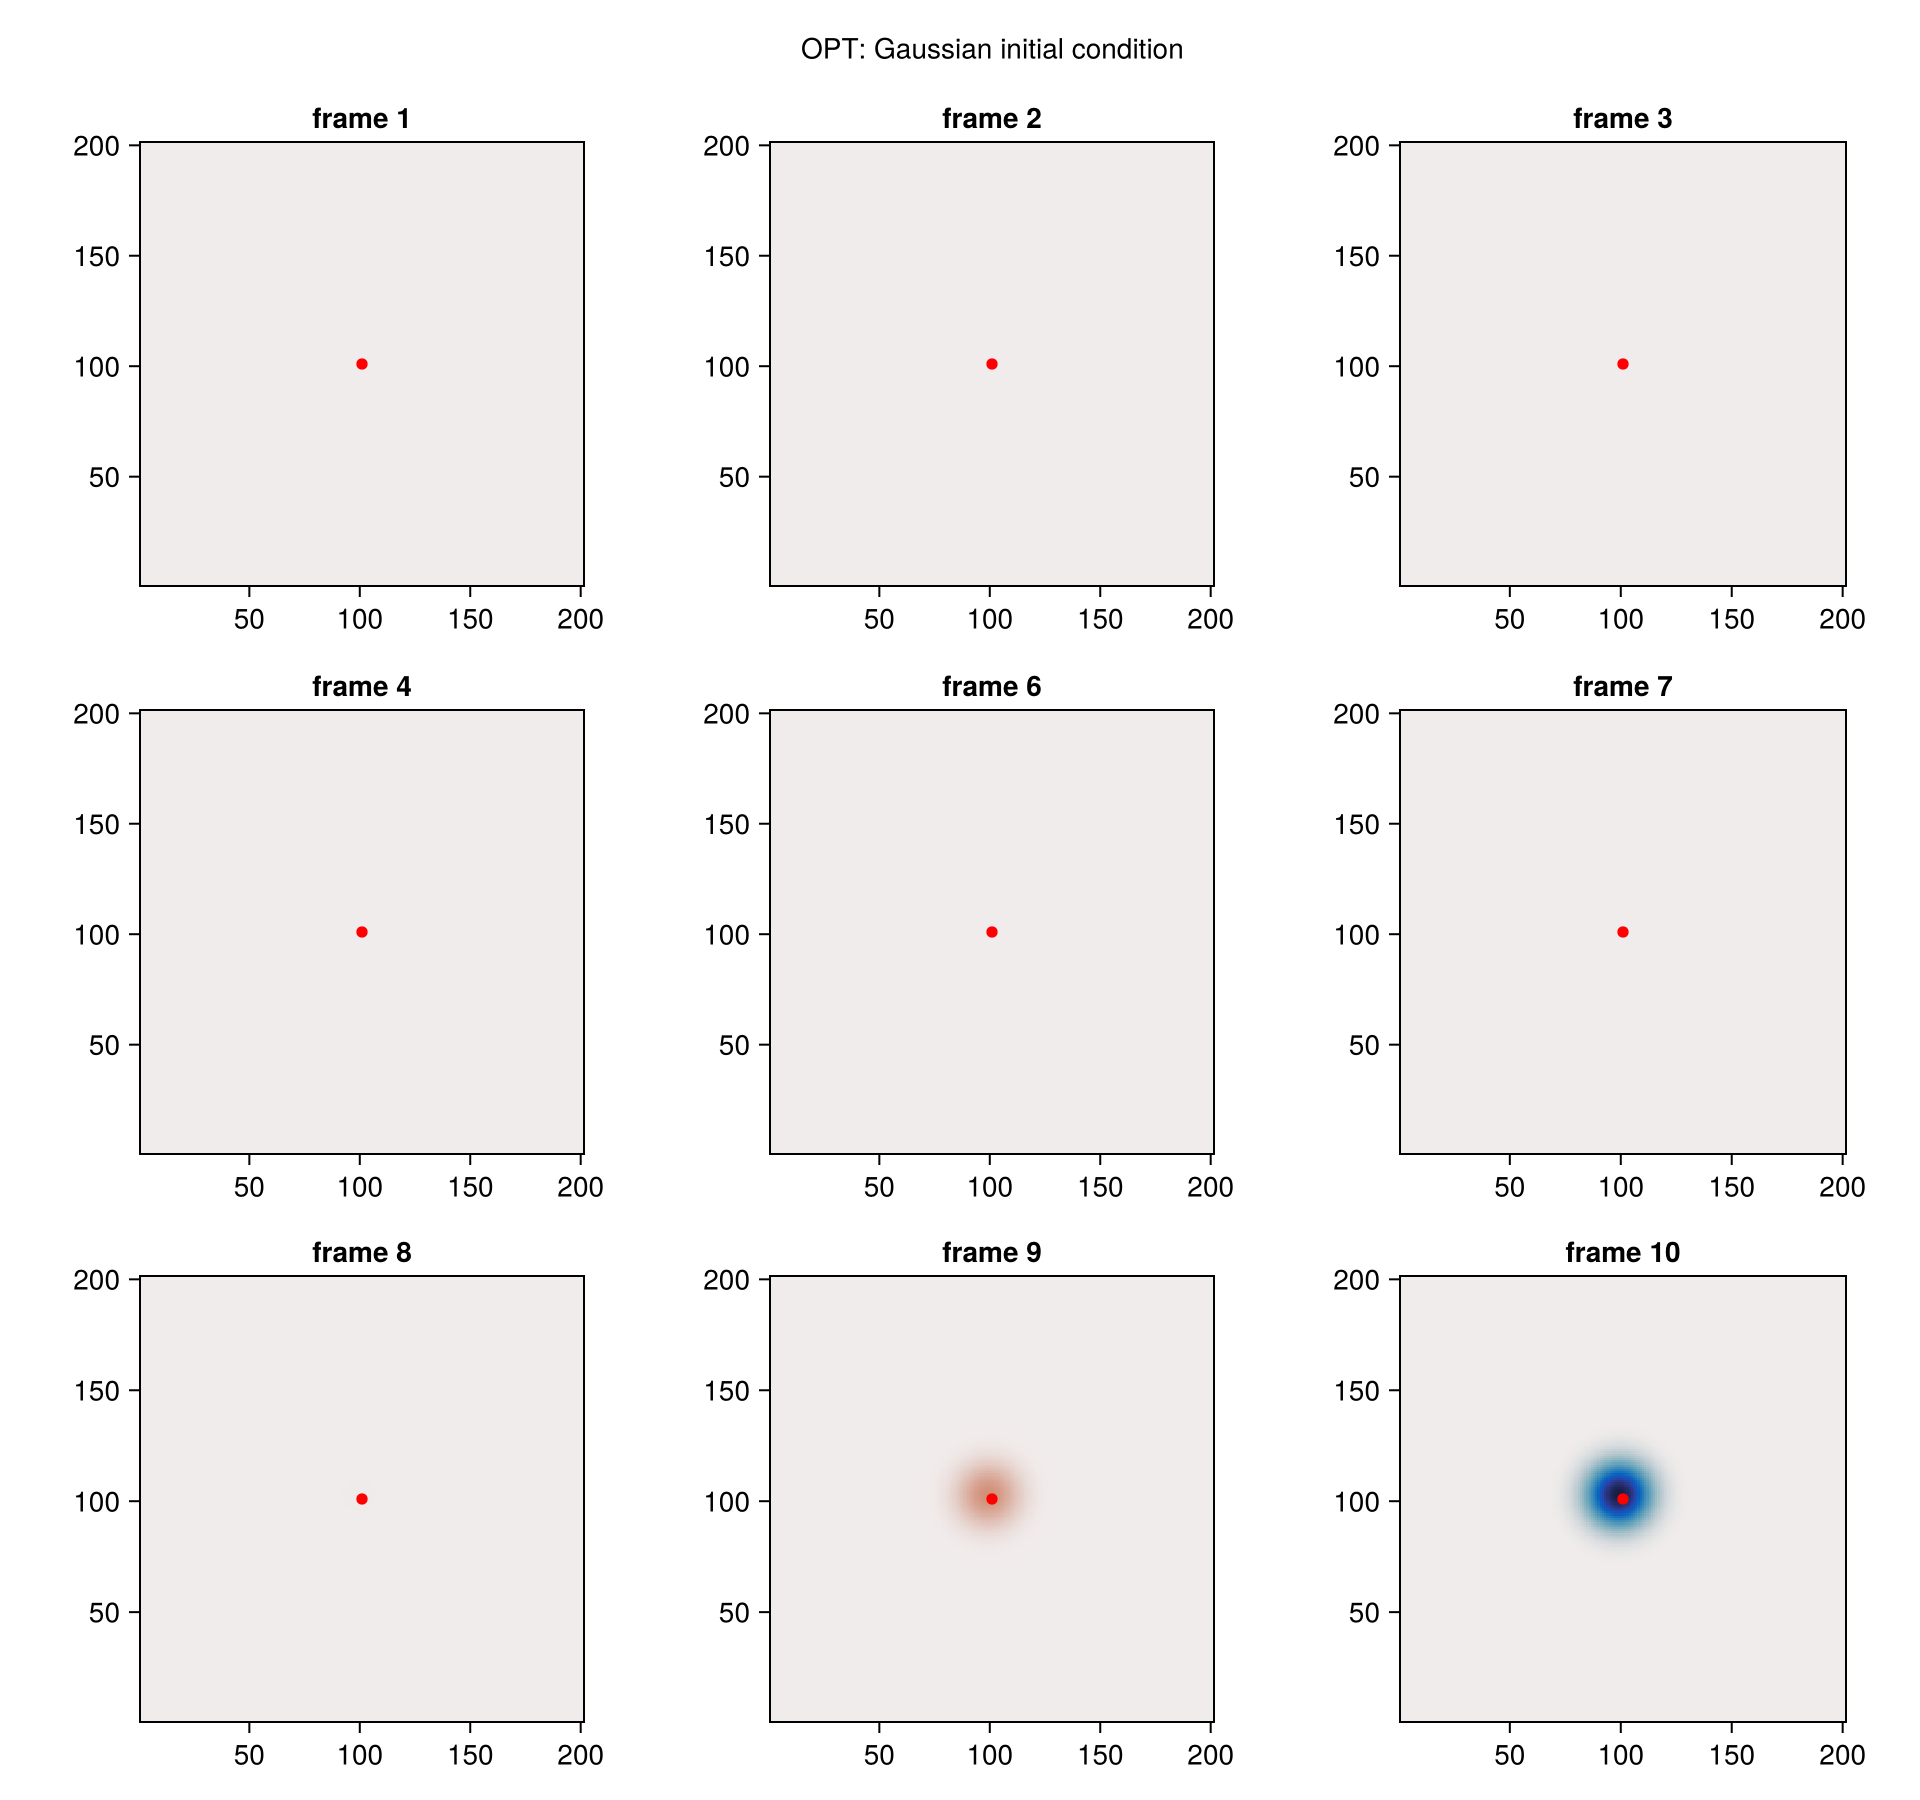

In [10]:
fig_opt = plot_wave_snapshots(
    frames_opt;
    sourcePoint=center,
    title="OPT: Gaussian initial condition",
)
fig_opt


In [11]:
Main.flexOPT.opt_integral_order = :ln_lc
toy_a = build_toy_opt_prepared(velocity_value=velocity_value,
    shape=shape,
    dx=dx,
    cfl=cfl,
    pointsInSpace=pointsInSpace,
    pointsInTime=pointsInTime,
    supplementaryOrder=supplementaryOrder,
    orderBspace=orderBspace,
    orderBtime=orderBtime,)
st_a = operator_stencil_at_point(toy_a.numOps, center; which=:left)
stencil_time_summary(st_a)
st_a

(vars, iVars) = (v(x, y), 1)
(vars, iVars) = (v(x, y), 1)
pointsIndices = availablePointsConfigurations[iConfigGeometry] = SVector{3, Int64}[[1, 1, 1] [1, 2, 1] [1, 3, 1]; [2, 1, 1] [2, 2, 1] [2, 3, 1]; [3, 1, 1] [3, 2, 1] [3, 3, 1];;; [1, 1, 2] [1, 2, 2] [1, 3, 2]; [2, 1, 2] [2, 2, 2] [2, 3, 2]; [3, 1, 2] [3, 2, 2] [3, 3, 2];;; [1, 1, 3] [1, 2, 3] [1, 3, 3]; [2, 1, 3] [2, 2, 3] [2, 3, 3]; [3, 1, 3] [3, 2, 3] [3, 3, 3]]
middleLinearν = centrePointConfigurations[iConfigGeometry] = 14
μPoints = availableμPoints[iConfigGeometry] = SVector{3, Float64}[[2.0, 2.0, 2.0];;;]
μᶜPoints = availableμᶜPoints[iConfigGeometry] = SVector{3, Float64}[[2.0, 2.0, 2.0];;;]
μaxes = availableμaxes[iConfigGeometry] = ([2.0], [2.0], [2.0])
μᶜaxes = availableμᶜaxes[iConfigGeometry] = ([2.0], [2.0], [2.0])
size(μPoints) = (1, 1, 1)
pointν = pointsIndices[middleLinearν] = [2, 2, 2]
(typeof(μPoints), μPoints[1], typeof(pointsIndices)) = (Array{SVector{3, Float64}, 3}, [2.0, 2.0, 2.0], Array{SVector{3, Int64}, 3})

27-element Vector{NamedTuple}:
 (time_slot = 1, time_role = :past_2, offset = (-1, -1), coef = -1.6477417736694094e-22, abscoef = 1.6477417736694094e-22, col = 59995)
 (time_slot = 1, time_role = :past_2, offset = (-1, 0), coef = -1.7898248122921792e-9, abscoef = 1.7898248122921792e-9, col = 60598)
 (time_slot = 1, time_role = :past_2, offset = (-1, 1), coef = 6.17530229256566e-23, abscoef = 6.17530229256566e-23, col = 61201)
 (time_slot = 1, time_role = :past_2, offset = (0, -1), coef = -1.077455981700553e-9, abscoef = 1.077455981700553e-9, col = 59998)
 (time_slot = 1, time_role = :past_2, offset = (0, 0), coef = 1.7153950821117613e-8, abscoef = 1.7153950821117613e-8, col = 60601)
 (time_slot = 1, time_role = :past_2, offset = (0, 1), coef = 2.863133845371789e-9, abscoef = 2.863133845371789e-9, col = 61204)
 (time_slot = 1, time_role = :past_2, offset = (1, -1), coef = 6.18947274886691e-22, abscoef = 6.18947274886691e-22, col = 60001)
 (time_slot = 1, time_role = :past_2, offset = (1

In [12]:
Main.flexOPT.opt_integral_order = :lc_ln
toy_b = build_toy_opt_prepared(velocity_value=velocity_value,
    shape=shape,
    dx=dx,
    cfl=cfl,
    pointsInSpace=pointsInSpace,
    pointsInTime=pointsInTime,
    supplementaryOrder=supplementaryOrder,
    orderBspace=orderBspace,
    orderBtime=orderBtime,)
st_b = operator_stencil_at_point(toy_b.numOps, center; which=:left)
stencil_time_summary(st_b)
st_b

(vars, iVars) = (v(x, y), 1)
(vars, iVars) = (v(x, y), 1)
pointsIndices = availablePointsConfigurations[iConfigGeometry] = SVector{3, Int64}[[1, 1, 1] [1, 2, 1] [1, 3, 1]; [2, 1, 1] [2, 2, 1] [2, 3, 1]; [3, 1, 1] [3, 2, 1] [3, 3, 1];;; [1, 1, 2] [1, 2, 2] [1, 3, 2]; [2, 1, 2] [2, 2, 2] [2, 3, 2]; [3, 1, 2] [3, 2, 2] [3, 3, 2];;; [1, 1, 3] [1, 2, 3] [1, 3, 3]; [2, 1, 3] [2, 2, 3] [2, 3, 3]; [3, 1, 3] [3, 2, 3] [3, 3, 3]]
middleLinearν = centrePointConfigurations[iConfigGeometry] = 14
μPoints = availableμPoints[iConfigGeometry] = SVector{3, Float64}[[2.0, 2.0, 2.0];;;]
μᶜPoints = availableμᶜPoints[iConfigGeometry] = SVector{3, Float64}[[2.0, 2.0, 2.0];;;]
μaxes = availableμaxes[iConfigGeometry] = ([2.0], [2.0], [2.0])
μᶜaxes = availableμᶜaxes[iConfigGeometry] = ([2.0], [2.0], [2.0])
size(μPoints) = (1, 1, 1)
pointν = pointsIndices[middleLinearν] = [2, 2, 2]
(typeof(μPoints), μPoints[1], typeof(pointsIndices)) = (Array{SVector{3, Float64}, 3}, [2.0, 2.0, 2.0], Array{SVector{3, Int64}, 3})

27-element Vector{NamedTuple}:
 (time_slot = 1, time_role = :past_2, offset = (-1, -1), coef = -1.6477417736694094e-22, abscoef = 1.6477417736694094e-22, col = 59995)
 (time_slot = 1, time_role = :past_2, offset = (-1, 0), coef = -1.7898248122921792e-9, abscoef = 1.7898248122921792e-9, col = 60598)
 (time_slot = 1, time_role = :past_2, offset = (-1, 1), coef = 6.17530229256566e-23, abscoef = 6.17530229256566e-23, col = 61201)
 (time_slot = 1, time_role = :past_2, offset = (0, -1), coef = -1.077455981700553e-9, abscoef = 1.077455981700553e-9, col = 59998)
 (time_slot = 1, time_role = :past_2, offset = (0, 0), coef = 1.7153950821117613e-8, abscoef = 1.7153950821117613e-8, col = 60601)
 (time_slot = 1, time_role = :past_2, offset = (0, 1), coef = 2.863133845371789e-9, abscoef = 2.863133845371789e-9, col = 61204)
 (time_slot = 1, time_role = :past_2, offset = (1, -1), coef = 6.18947274886691e-22, abscoef = 6.18947274886691e-22, col = 60001)
 (time_slot = 1, time_role = :past_2, offset = (1

## 6. FD vs OPT Drift Comparison

In [13]:
drift_comparison = (
    fd_final_drift = fd_drift[end],
    opt_final_drift = opt_drift[end],
    fd_final_argmax = fd_argmax[end],
    opt_final_argmax = opt_argmax[end],
    fd_final_symmetry = fd_symmetry[end],
    opt_final_symmetry = opt_symmetry[end],
)
drift_comparison


(fd_final_drift = (frame = 61, cm_x = 101.00000000000011, cm_z = 100.99999999999959, drift_x = 1.1368683772161603e-13, drift_z = -4.121147867408581e-13, maxabs = 0.12650212646124115), opt_final_drift = (frame = 10, cm_x = 99.22004372893048, cm_z = 102.95117398177938, drift_x = -1.7799562710695227, drift_z = 1.9511739817793767, maxabs = 2.5823860093739683e12), fd_final_argmax = (frame = 61, maxpoint = CartesianIndex(43, 165), dx = -58, dz = 64, value = 0.12650212646124115, maxabs = 0.12650212646124115), opt_final_argmax = (frame = 10, maxpoint = CartesianIndex(99, 103), dx = -2, dz = 2, value = -2.5823860093739683e12, maxabs = 2.5823860093739683e12), fd_final_symmetry = (frame = 61, lr = 1.1842581322338107e-15, ud = 1.325636187332138e-15, diag = 1.412088476802089e-15), opt_final_symmetry = (frame = 10, lr = 0.1414206762996639, ud = 0.15579776570420556, diag = 0.21031061388828773))

## 7. Optional OPT Parameter Sweep

In [14]:
# Optional: change these values and rerun to see whether drift is caused by OPT parameters.
# Some implicit OPT future blocks can be singular or non-finite; those cases are reported and skipped.
parameter_cases = [(3,2), (3,0), (5,2)]

sweep_rows = NamedTuple[]
for (pspace, supp) in parameter_cases
    println("building OPT case pointsInSpace=$pspace supplementaryOrder=$supp")
    a_report = nothing
    try
        toy = build_toy_opt_prepared(
            velocity_value=velocity_value,
            shape=shape,
            dx=dx,
            cfl=cfl,
            pointsInSpace=pspace,
            pointsInTime=pointsInTime,
            supplementaryOrder=supp,
            orderBspace=orderBspace,
            orderBtime=orderBtime,
        )
        a_report = implicit_matrix_report(toy.prepared)
        if a_report.stored_nonfinite > 0 || a_report.zero_rows_finite > 0
            push!(sweep_rows, (
                pointsInSpace=pspace,
                supplementaryOrder=supp,
                status=:bad_A_unknown,
                matrix_report=a_report,
                nframes=0,
                final_drift=nothing,
                final_symmetry=nothing,
                final_max=NaN,
            ))
            @warn "Skipping OPT case because A_unknown is non-finite or has finite-zero rows" pointsInSpace=pspace supplementaryOrder=supp matrix_report=a_report
            continue
        end
        fr = propagate_linear_frames_from_initial(toy.prepared, init_gaussian, init_gaussian, Nt; store_every=store_every, blowup_limit=1e12)
        dr = drift_report(fr, center)
        sy = symmetry_report(fr, center)
        push!(sweep_rows, (
            pointsInSpace=pspace,
            supplementaryOrder=supp,
            status=:ok,
            matrix_report=a_report,
            nframes=length(fr),
            final_drift=dr[end],
            final_symmetry=sy[end],
            final_max=maximum(abs, fr[end]),
        ))
    catch err
        push!(sweep_rows, (
            pointsInSpace=pspace,
            supplementaryOrder=supp,
            status=Symbol(nameof(typeof(err))),
            matrix_report=a_report,
            nframes=0,
            final_drift=nothing,
            final_symmetry=nothing,
            final_max=NaN,
        ))
        @warn "Skipping failed OPT case" pointsInSpace=pspace supplementaryOrder=supp matrix_report=a_report exception=(err, catch_backtrace())
    end
end
sweep_rows


building OPT case pointsInSpace=3 supplementaryOrder=2
(vars, iVars) = (v(x, y), 1)
(vars, iVars) = (v(x, y), 1)
pointsIndices = availablePointsConfigurations[iConfigGeometry] = SVector{3, Int64}[[1, 1, 1] [1, 2, 1] [1, 3, 1]; [2, 1, 1] [2, 2, 1] [2, 3, 1]; [3, 1, 1] [3, 2, 1] [3, 3, 1];;; [1, 1, 2] [1, 2, 2] [1, 3, 2]; [2, 1, 2] [2, 2, 2] [2, 3, 2]; [3, 1, 2] [3, 2, 2] [3, 3, 2];;; [1, 1, 3] [1, 2, 3] [1, 3, 3]; [2, 1, 3] [2, 2, 3] [2, 3, 3]; [3, 1, 3] [3, 2, 3] [3, 3, 3]]
middleLinearν = centrePointConfigurations[iConfigGeometry] = 14
μPoints = availableμPoints[iConfigGeometry] = SVector{3, Float64}[[2.0, 2.0, 2.0];;;]
μᶜPoints = availableμᶜPoints[iConfigGeometry] = SVector{3, Float64}[[2.0, 2.0, 2.0];;;]
μaxes = availableμaxes[iConfigGeometry] = ([2.0], [2.0], [2.0])
μᶜaxes = availableμᶜaxes[iConfigGeometry] = ([2.0], [2.0], [2.0])
size(μPoints) = (1, 1, 1)
pointν = pointsIndices[middleLinearν] = [2, 2, 2]
(typeof(μPoints), μPoints[1], typeof(pointsIndices)) = (Array{SVector{3, Floa

┌ Warning: Stopping because wavefield blew up
│   it = 25
│   umax = 2.5823860093739683e12
│   blowup_limit = 1.0e12
└ @ Main /Users/nobuaki/Documents/Github/flexOPT/notebooks/temporaryHelpers.jl:156


building OPT case pointsInSpace=3 supplementaryOrder=0
(vars, iVars) = (v(x, y), 1)
(vars, iVars) = (v(x, y), 1)
pointsIndices = availablePointsConfigurations[iConfigGeometry] = SVector{3, Int64}[[1, 1, 1] [1, 2, 1] [1, 3, 1]; [2, 1, 1] [2, 2, 1] [2, 3, 1]; [3, 1, 1] [3, 2, 1] [3, 3, 1];;; [1, 1, 2] [1, 2, 2] [1, 3, 2]; [2, 1, 2] [2, 2, 2] [2, 3, 2]; [3, 1, 2] [3, 2, 2] [3, 3, 2];;; [1, 1, 3] [1, 2, 3] [1, 3, 3]; [2, 1, 3] [2, 2, 3] [2, 3, 3]; [3, 1, 3] [3, 2, 3] [3, 3, 3]]
middleLinearν = centrePointConfigurations[iConfigGeometry] = 14
μPoints = availableμPoints[iConfigGeometry] = SVector{3, Float64}[[2.0, 2.0, 2.0];;;]
μᶜPoints = availableμᶜPoints[iConfigGeometry] = SVector{3, Float64}[[2.0, 2.0, 2.0];;;]
μaxes = availableμaxes[iConfigGeometry] = ([2.0], [2.0], [2.0])
μᶜaxes = availableμᶜaxes[iConfigGeometry] = ([2.0], [2.0], [2.0])
size(μPoints) = (1, 1, 1)
pointν = pointsIndices[middleLinearν] = [2, 2, 2]
(typeof(μPoints), μPoints[1], typeof(pointsIndices)) = (Array{SVector{3, Floa

┌ Warning: Stopping because wavefield blew up
│   it = 22
│   umax = 2.862328316755941e12
│   blowup_limit = 1.0e12
└ @ Main /Users/nobuaki/Documents/Github/flexOPT/notebooks/temporaryHelpers.jl:156


building OPT case pointsInSpace=5 supplementaryOrder=2
(vars, iVars) = (v(x, y), 1)
(vars, iVars) = (v(x, y), 1)
pointsIndices = availablePointsConfigurations[iConfigGeometry] = SVector{3, Int64}[[1, 1, 1] [1, 2, 1] [1, 3, 1] [1, 4, 1] [1, 5, 1]; [2, 1, 1] [2, 2, 1] [2, 3, 1] [2, 4, 1] [2, 5, 1]; [3, 1, 1] [3, 2, 1] [3, 3, 1] [3, 4, 1] [3, 5, 1]; [4, 1, 1] [4, 2, 1] [4, 3, 1] [4, 4, 1] [4, 5, 1]; [5, 1, 1] [5, 2, 1] [5, 3, 1] [5, 4, 1] [5, 5, 1];;; [1, 1, 2] [1, 2, 2] [1, 3, 2] [1, 4, 2] [1, 5, 2]; [2, 1, 2] [2, 2, 2] [2, 3, 2] [2, 4, 2] [2, 5, 2]; [3, 1, 2] [3, 2, 2] [3, 3, 2] [3, 4, 2] [3, 5, 2]; [4, 1, 2] [4, 2, 2] [4, 3, 2] [4, 4, 2] [4, 5, 2]; [5, 1, 2] [5, 2, 2] [5, 3, 2] [5, 4, 2] [5, 5, 2];;; [1, 1, 3] [1, 2, 3] [1, 3, 3] [1, 4, 3] [1, 5, 3]; [2, 1, 3] [2, 2, 3] [2, 3, 3] [2, 4, 3] [2, 5, 3]; [3, 1, 3] [3, 2, 3] [3, 3, 3] [3, 4, 3] [3, 5, 3]; [4, 1, 3] [4, 2, 3] [4, 3, 3] [4, 4, 3] [4, 5, 3]; [5, 1, 3] [5, 2, 3] [5, 3, 3] [5, 4, 3] [5, 5, 3]]
middleLinearν = centrePointConfigur

┌ Error: A_unknown factorization failed
│   exception = (SingularException(0), Union{Ptr{Nothing}, Base.InterpreterIP}[Ptr{Nothing}(0x0000000347aaeaeb), Ptr{Nothing}(0x0000000347abc297), Ptr{Nothing}(0x0000000347abc7e3), Ptr{Nothing}(0x0000000347c44fe3), Ptr{Nothing}(0x000000010734302b), Ptr{Nothing}(0x0000000107342e0f), Ptr{Nothing}(0x000000010734406b), Ptr{Nothing}(0x000000011b66686b), Ptr{Nothing}(0x0000000113064247), Ptr{Nothing}(0x0000000107314c73), Ptr{Nothing}(0x000000011301c513), Ptr{Nothing}(0x000000011304431f), Ptr{Nothing}(0x000000011305410f), Ptr{Nothing}(0x00000001130541d3), Ptr{Nothing}(0x000000012dc6c837), Ptr{Nothing}(0x000000012dc6cbdf), Ptr{Nothing}(0x0000000112d7d2b3), Ptr{Nothing}(0x0000000112d9405f), Ptr{Nothing}(0x0000000112d94123), Ptr{Nothing}(0x0000000112bdcd77), Ptr{Nothing}(0x000000010734302b), Ptr{Nothing}(0x0000000107342e0f), Ptr{Nothing}(0x000000010734406b), Ptr{Nothing}(0x000000011b66686b), Ptr{Nothing}(0x000000011c915f0f), Ptr{Nothing}(0x000000011c2d290f

3-element Vector{NamedTuple}:
 (pointsInSpace = 3, supplementaryOrder = 2, status = :ok, matrix_report = (size = (40401, 40401), nnz = 361201, stored_finite = 361201, stored_nonfinite = 0, stored_nan = 0, stored_inf = 0, zero_rows_finite = 0, rows_with_nonfinite = 0, finite_abs_min = 1.1571303488240596e-22, finite_abs_median = 2.90794940549532e-9, finite_abs_max = 5.079253057108472e-8, diag_finite_count = 40401, diag_nonfinite_count = 0, diag_abs_min = 5.079253057108472e-8, diag_abs_median = 5.079253057108472e-8, diag_abs_max = 5.079253057108472e-8, finite_row_abs_min = 5.989989070779101e-8, finite_row_abs_max = 1.1178250227642247e-7), nframes = 10, final_drift = (frame = 10, cm_x = 99.22004372893048, cm_z = 102.95117398177938, drift_x = -1.7799562710695227, drift_z = 1.9511739817793767, maxabs = 2.5823860093739683e12), final_symmetry = (frame = 10, lr = 0.1414206762996639, ud = 0.15579776570420556, diag = 0.21031061388828773), final_max = 2.5823860093739683e12)
 (pointsInSpace = 3, su